In [2]:
import pandas as pd
import numpy as np

In [15]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import optuna
from sklearn.model_selection import cross_val_score
from category_encoders import TargetEncoder
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

In [16]:
df = pd.read_csv('data/drom_archive_cleaned_2018-2025.csv')
df_cheap = df[df['Цена'] <= 700_000]
df_mid = df[(df['Цена'] >= 500_000) & (df['Цена'] < 2_000_000)]
df_exp = df[df['Цена'] >= 2_000_000]

                  Название машины       Год      Цена  Объем двигателя  \
Название машины          1.000000  0.012770  0.072441         0.128533   
Год                      0.012770  1.000000  0.385354         0.413829   
Цена                     0.072441  0.385354  1.000000         0.214657   
Объем двигателя          0.128533  0.413829  0.214657         1.000000   
Тип двигателя            0.049636  0.127847  0.097687         0.145034   
Мощность                 0.230670  0.326264  0.264839         0.890608   
Коробка передач          0.053684  0.053553  0.085851         0.041227   
Привод                   0.059674  0.258264  0.191431         0.493160   
Пробег                   0.003123  0.643971  0.205362         0.302182   
Руль                     0.229692  0.196104  0.100110         0.236813   
Поколение                0.089284  0.058615  0.091321         0.070490   
Рестайлинг               0.061421  0.107370  0.050652         0.050678   
Тип кузова               0.052048  0.1

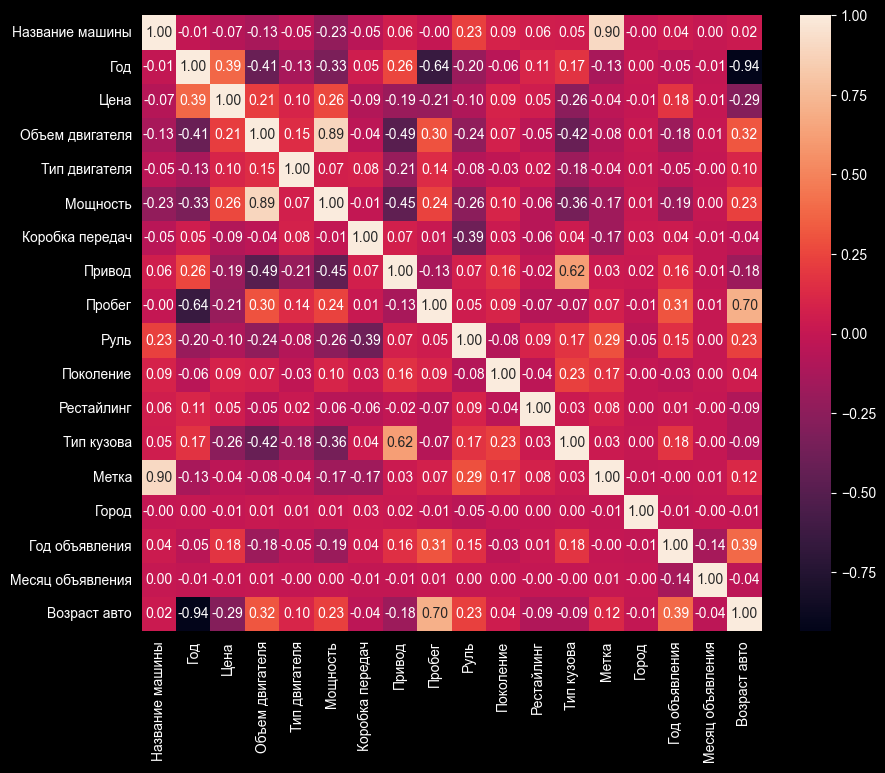

In [21]:
#categorical = ['Тип двигателя', 'Коробка передач', 'Привод', 'Поколение', 'Рестайлинг',
#               'Тип кузова', 'Метка', 'Город']
# = ['Год', 'Объем двигателя', 'Мощность', 'Пробег', 'Возраст авто']
categorical_target = ['Метка', 'Город', 'Поколение']      # Target Encoding
categorical_onehot = ['Тип двигателя', 'Коробка передач', 'Привод', 'Рестайлинг', 'Тип кузова']  # OneHot
numerical = ['Год', 'Объем двигателя', 'Мощность', 'Пробег', 'Возраст авто']
categories = ['Название машины', 'Тип двигателя', 'Коробка передач', 'Привод', 'Тип кузова', 'Метка', 'Город', 'Руль']
label_encoder = LabelEncoder()
df_mid_encode = df_mid.copy()

for col in categories:
    df_mid_encode[col] = label_encoder.fit_transform(df_mid_encode[col])

corr_matrix = df_mid_encode.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f')
print(abs(corr_matrix))

In [13]:
'''
preprocessor = ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical), ('num', 'passthrough', numerical)], remainder='drop')
'''
preprocessor = ColumnTransformer(
    transformers=[
        ('target', TargetEncoder(), categorical_target),
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_onehot),
        ('num', 'passthrough', numerical)
    ]
)
print(df_mid['Пробег'].var())
print(df_mid['Год'].var())
print(df_mid['Объем двигателя'].var())
print(df_mid['Мощность'].var())
print(df_mid['Возраст авто'].var())

7345340034.908364
28.706663166918652
0.5588670577867362
3559.3815778195863
33.91714076864154


In [27]:
y = df_mid['Цена']
X = df_mid.drop('Цена', axis=1)

X_train = X[X['Год объявления'] <= 2023]
X_test = X[X['Год объявления'] >= 2024]

y_train = y[X['Год объявления'] <= 2023]
y_test = y[X['Год объявления'] >= 2024]
'''
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=1000,
        n_jobs=-1,
        random_state=42,
        eval_metric='rmse'
    ))
])
'''
'''
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=2000,
        n_jobs=-1,
        random_state=42,
        eval_metric='rmse'
    ))
])
model.fit(X_train, y_train, regressor__verbose=True)
y_pred = model.predict(X_test)
'''

"\nmodel = Pipeline([\n    ('preprocessor', preprocessor),\n    ('regressor', XGBRegressor(\n        n_estimators=2000,\n        n_jobs=-1,\n        random_state=42,\n        eval_metric='rmse'\n    ))\n])\nmodel.fit(X_train, y_train, regressor__verbose=True)\ny_pred = model.predict(X_test)\n"

In [28]:
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline


def objective_gpu(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 2000),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 8),
        "gamma": trial.suggest_float("gamma", 0, 3),
    }

    model = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', xgb.XGBRegressor(
            **params,
            device="cuda",           # GPU
            tree_method="hist",      # обязательный для GPU
            eval_metric="rmse",
            random_state=42
        ))
    ])

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    ).mean()

    return score


study = optuna.create_study(
    study_name="xgb_gpu_car_price",
    direction="maximize"
)

study.optimize(
    objective_gpu,
    n_trials=30,
    show_progress_bar=True
)

print("Best params:", study.best_params)

[I 2026-03-28 22:57:22,146] A new study created in memory with name: xgb_gpu_car_price
Best trial: 0. Best value: -132976:   3%|▎         | 1/30 [00:22<10:43, 22.18s/it]

[I 2026-03-28 22:57:44,325] Trial 0 finished with value: -132976.02339065334 and parameters: {'n_estimators': 1119, 'max_depth': 6, 'learning_rate': 0.09400635816434887, 'subsample': 0.6338568910579023, 'colsample_bytree': 0.8904181311079675, 'min_child_weight': 4, 'gamma': 0.483194931694655}. Best is trial 0 with value: -132976.02339065334.


Best trial: 1. Best value: -131478:   7%|▋         | 2/30 [00:54<13:05, 28.06s/it]

[I 2026-03-28 22:58:16,508] Trial 1 finished with value: -131478.38457367968 and parameters: {'n_estimators': 1420, 'max_depth': 8, 'learning_rate': 0.08476726460778157, 'subsample': 0.8154452581310565, 'colsample_bytree': 0.7178297140206238, 'min_child_weight': 7, 'gamma': 2.2539692401879217}. Best is trial 1 with value: -131478.38457367968.


Best trial: 1. Best value: -131478:  10%|█         | 3/30 [01:14<10:55, 24.26s/it]

...

[I 2026-03-28 23:15:35,378] Trial 27 finished with value: -130297.37041746416 and parameters: {'n_estimators': 1525, 'max_depth': 9, 'learning_rate': 0.03041728283134835, 'subsample': 0.9220488101822774, 'colsample_bytree': 0.8429458139948506, 'min_child_weight': 8, 'gamma': 0.9680930709089315}. Best is trial 22 with value: -129808.76808464788.


Best trial: 22. Best value: -129809:  97%|█████████▋| 29/30 [18:42<00:43, 43.25s/it]

[I 2026-03-28 23:16:04,177] Trial 28 finished with value: -130829.0478387844 and parameters: {'n_estimators': 1689, 'max_depth': 7, 'learning_rate': 0.06313903299988649, 'subsample': 0.9673752121908096, 'colsample_bytree': 0.7910689838721744, 'min_child_weight': 5, 'gamma': 0.5422352941003735}. Best is trial 22 with value: -129808.76808464788.


Best trial: 22. Best value: -129809: 100%|██████████| 30/30 [19:21<00:00, 38.71s/it]

[I 2026-03-28 23:16:43,389] Trial 29 finished with value: -130729.21590304298 and parameters: {'n_estimators': 1147, 'max_depth': 10, 'learning_rate': 0.018106202758223305, 'subsample': 0.6026181038310424, 'colsample_bytree': 0.9068618486954705, 'min_child_weight': 6, 'gamma': 0.6367895707388097}. Best is trial 22 with value: -129808.76808464788.
Best params: {'n_estimators': 1809, 'max_depth': 10, 'learning_rate': 0.019930562898106963, 'subsample': 0.9507953174403574, 'colsample_bytree': 0.7468730132046596, 'min_child_weight': 8, 'gamma': 1.1567257177325467}


In [29]:
best_params = study.best_params

final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(
        **best_params,
        device="cuda",
        tree_method="hist",
        eval_metric="rmse",
        random_state=42
    ))
])

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

In [30]:
xg_mse = mean_squared_error(y_test, y_pred)
xg_rmse = np.sqrt(xg_mse)
xg_mae = mean_absolute_error(y_test, y_pred)
xg_r2 = r2_score(y_test, y_pred)

In [31]:
pd.options.display.float_format = '{:_.2f}'.format
pd.DataFrame({
    'Метод оценки': ['Среднеквадратическая ошибка (MSE)', 'Среднеквадратическая ошибка (RMSE)', 'Средняя абсолютная ошибка (MAE)', 'Коэффицент детерминации (R^2)'],
    'Результаты': [xg_mse, xg_rmse, xg_mae, xg_r2]
})

,Метод оценки,Результаты
0,Среднеквадратическая ошибка (MSE),45_738_939_691.79
1,Среднеквадратическая ошибка (RMSE),213_866.64
2,Средняя абсолютная ошибка (MAE),161_924.16
3,Коэффицент детерминации (R^2),0.71


In [32]:
np.mean(df_mid['Цена'])

np.float64(937712.6615684894)

In [33]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"MAPE: {mape:.2%}")

MAPE: 15.15%


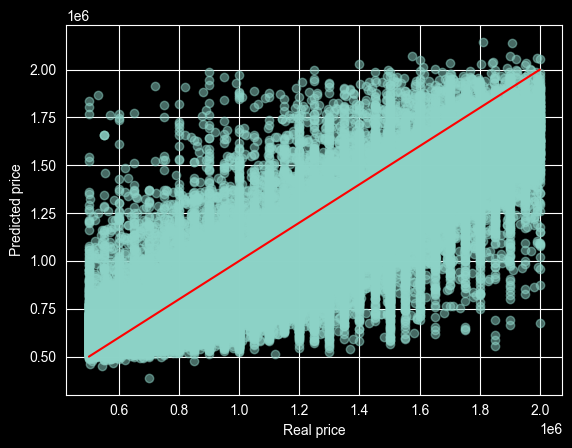

In [34]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Real price")
plt.ylabel("Predicted price")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.show()

In [1]:
errors = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, errors, alpha=0.3)

plt.axhline(0, color='red')

plt.xlabel("Предсказанная цена")
plt.ylabel("Ошибка")
plt.title("Residual Plot")

plt.show()

NameError: name 'y_test' is not defined